# The circle scenario

Put `N` drones evenly around a ring and tell each one to fly to the point diametrically opposite.
Every one of them heads straight through the centre, and all of them arrive there at the same moment.

This is the standard stress test for separation logic, and it is deliberately unfair:

- **Every aircraft conflicts with every other one.** Not one intruder to avoid, but `N − 1`, all at
  once.
- **The conflicts peak together.** There is no convenient sequence of pairwise problems to solve one
  at a time; they all come due at the same instant.
- **The symmetry gives no one priority.** In a two-aircraft crossing there is a natural asymmetry to
  break the tie. Here every drone sees the same picture, rotated. Whatever rule one applies, all the
  others apply it too — and identical reasoning from identical inputs is how two aircraft step into
  each other.

We start with four drones, but the count is a parameter throughout. The second half of this notebook
is about what happens as you turn it up, and then what happens once the drones can no longer see
each other perfectly.

In [1]:
%matplotlib inline
import dataclasses
import math

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.dpi"] = 130

from opencdarr import (
    M600, MVP, Agent, Comm, GnssNavigation, LastKnown, FTR, StateBased,
    create_aircraft, generator, root_seed_sequence, run_fleet, spawn,
)
from opencdarr.autopilot import WaypointAutopilot
from opencdarr.cns import BroadcastSchedule, lognormal_latency
from opencdarr.geo import forward, qdrdist
from opencdarr.mission import Mission

CENTRE = (52.0, 4.0)   # ring centre, (lat, lon)
RADIUS = 500.0         # ring radius [m]
SPEED = 10.0           # cruise speed [m/s]
RPZ = 50.0             # protected zone radius [m]

N_DRONES = 4           # <-- the parameter. Change it and rerun.

## Building the ring

Placing the drones is straightforward once you have `forward(lat, lon, bearing, distance)`, which
answers "start here, go this way this far — where do I end up?".

Drone `i` sits at bearing `360 i / N` from the centre. Its destination is the same distance out on
the opposite bearing, `+180°`. And since the straight line between those two points runs through the
centre, its initial heading is just that opposite bearing.

Two details below are worth calling out, because both are easy to get wrong:

- **Each drone carries a `WaypointAutopilot`, not a fixed heading.** It is genuinely flying *to* a
  destination, so once it has been pushed off course it turns back toward the goal. A fixed heading
  would drift away and never arrive.
- **The speed is capped through the performance envelope.** A multirotor chasing a position setpoint
  accelerates to whatever the airframe allows — for a stock `M600` that is 18 m/s, not the 10 m/s we
  asked for. Rebuilding the envelope with `v_max = speed` makes the cruise speed mean what it says.

In [2]:
def circle_fleet(n, radius=RADIUS, speed=SPEED, pos_ci95=0.0, vel_ci95=0.0):
    # n multirotors evenly spaced on a ring, each aimed at the point diametrically opposite.
    perf = dataclasses.replace(M600, v_max=speed, v_min=-speed)   # so "speed" is really the speed
    agents, goals = [], []
    for i in range(n):
        bearing = 360.0 * i / n
        start = forward(*CENTRE, bearing, radius)
        goal = forward(*CENTRE, (bearing + 180.0) % 360.0, radius)
        state = create_aircraft(
            perf, id=f"D{i:02d}", lat=start[0], lon=start[1],
            trk=(bearing + 180.0) % 360.0,     # straight at the centre
            gs=speed, pos_ci95=pos_ci95, vel_ci95=vel_ci95,
        )
        agents.append(Agent(state, perf, autopilot=WaypointAutopilot(
            Mission(goto=goal), capture_radius=30.0)))
        goals.append(goal)
    return agents, goals


def fly(agents, resolver, dt=0.5, t_max=600.0, **cns):
    # Fly until everyone has arrived (within 50 m of their goal) or t_max runs out.
    # done_timeout is pinned to t_max so the run does not stop early just because the
    # conflicts cleared -- we want the whole journey, arrival included.
    return run_fleet(
        agents, rpz=RPZ, t_lookahead=60.0, dt=dt,
        detector=StateBased(), resolver=resolver, recovery=FTR(),
        t_max=t_max, done_timeout=t_max, stop_within=50.0, record=True, **cns,
    )


def enu(run):
    # Every aircraft's track as metres east/north of the ring centre.
    frames = run.frames.frames
    tracks = []
    for k in range(len(frames[0].states)):
        pts = []
        for f in frames:
            s = f.states[k]
            qdr, dist = qdrdist(*CENTRE, s.lat, s.lon)
            a = math.radians(qdr)
            pts.append((dist * math.sin(a), dist * math.cos(a)))
        tracks.append(np.array(pts))
    return np.array([f.t for f in frames]), tracks


agents, goals = circle_fleet(N_DRONES)
for a, g in zip(agents, goals):
    s = a.state
    print(f"{s.id}  starts at bearing {qdrdist(*CENTRE, s.lat, s.lon)[0]:>5.0f}° "
          f"heading {s.trk:>5.0f}°  ->  goal at bearing {qdrdist(*CENTRE, *g)[0]:>5.0f}°")

D00  starts at bearing     0° heading   180°  ->  goal at bearing   180°
D01  starts at bearing    90° heading   270°  ->  goal at bearing   270°
D02  starts at bearing   180° heading     0°  ->  goal at bearing     0°
D03  starts at bearing   270° heading    90°  ->  goal at bearing    90°


Four drones at 0°, 90°, 180° and 270°, each heading for the bearing 180° away. Their paths are two
diameters crossing at the centre.

## With no separation logic at all

Before switching anything on, fly it with `resolver=None` — the drones detect each other but do
nothing about it. This is the baseline the scenario is built to produce:

In [3]:
free = fly(circle_fleet(N_DRONES)[0], resolver=None)

print(f"conflict detected:  {free.conflict}")
print(f"separation lost:    {free.los}")
print(f"closest approach:   {free.min_sep:.2f} m")

conflict detected:  True
separation lost:    True
closest approach:   0.00 m


Zero. Not "small" — the drones occupy the same point at the same instant, because that is what
aiming them all at one centre does.

That is the scenario working as intended. It is not a realistic traffic sample; it is a worst case
constructed so that separation logic has to actually work to produce a non-zero number.

## Switching resolution on

Now the same fleet with **MVP** doing the avoiding. MVP treats each intruder as a repulsive
contribution and **adds** them up, which is what lets it face `N − 1` intruders at once rather than
only the nearest one.

In [4]:
solved = fly(circle_fleet(N_DRONES)[0], MVP(1.05))

print(f"separation lost:    {solved.los}")
print(f"closest approach:   {solved.min_sep:.1f} m   (protected zone {RPZ:.0f} m)")
print(f"flight time:        {solved.frames.frames[-1].t:.0f} s")

separation lost:    False
closest approach:   52.5 m   (protected zone 50 m)
flight time:        98 s


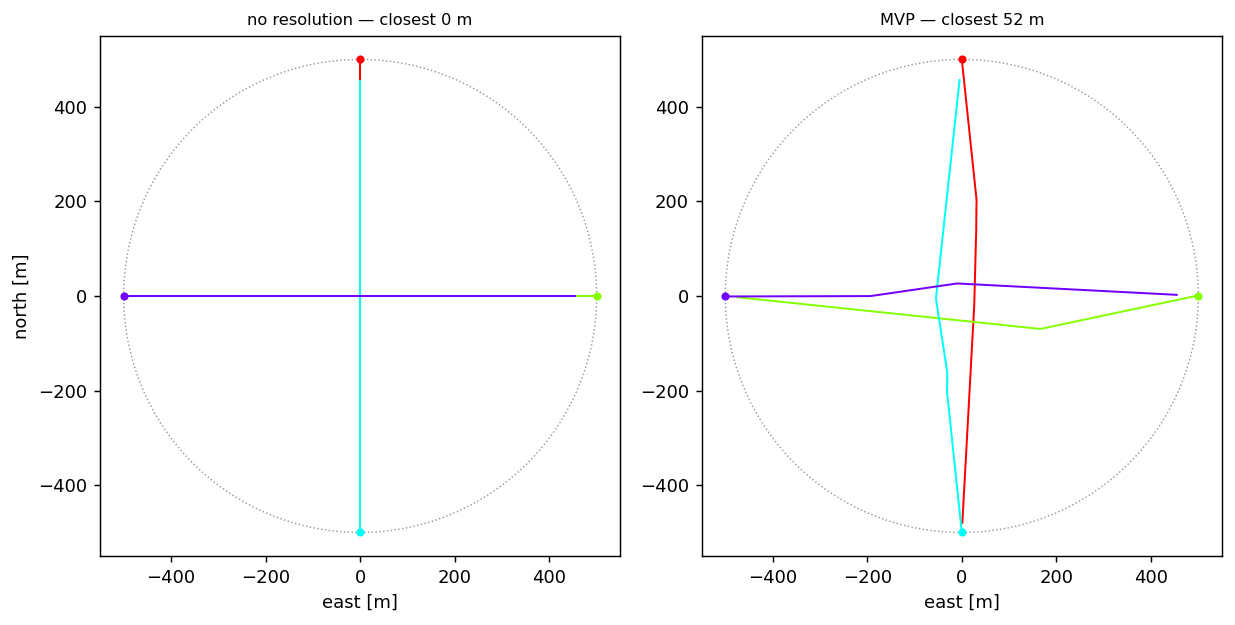

In [5]:
def draw_tracks(ax, run, title):
    _, tracks = enu(run)
    n = len(tracks)
    for k, xy in enumerate(tracks):
        colour = plt.cm.hsv(k / n)
        ax.plot(xy[:, 0], xy[:, 1], lw=1.1, color=colour)
        ax.plot(xy[0, 0], xy[0, 1], "o", ms=3.5, color=colour)
    ax.add_patch(plt.Circle((0, 0), RADIUS, fill=False, ls=":", lw=0.8, color="0.6"))
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("east [m]")


fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(9.6, 4.9))
draw_tracks(ax0, free, f"no resolution — closest {free.min_sep:.0f} m")
draw_tracks(ax1, solved, f"MVP — closest {solved.min_sep:.0f} m")
ax0.set_ylabel("north [m]")
fig.tight_layout()

Dots mark where each drone started; the dotted circle is the ring.

On the left, four straight lines through a single point. On the right the same four drones swing
wide, pass around the middle, and close back onto their destinations.

Look at which way each one swings: every drone deviates to **its own left**. The one flying south
goes east, the one flying north goes west, and so on around the ring. Nobody agreed on that. There
is no priority rule and no circulation convention in the code — each drone independently sums the
pushes from the other three, and because they are all solving the same problem the same way, a
consistent rotation falls out of the symmetry.

The separation history shows the timing:

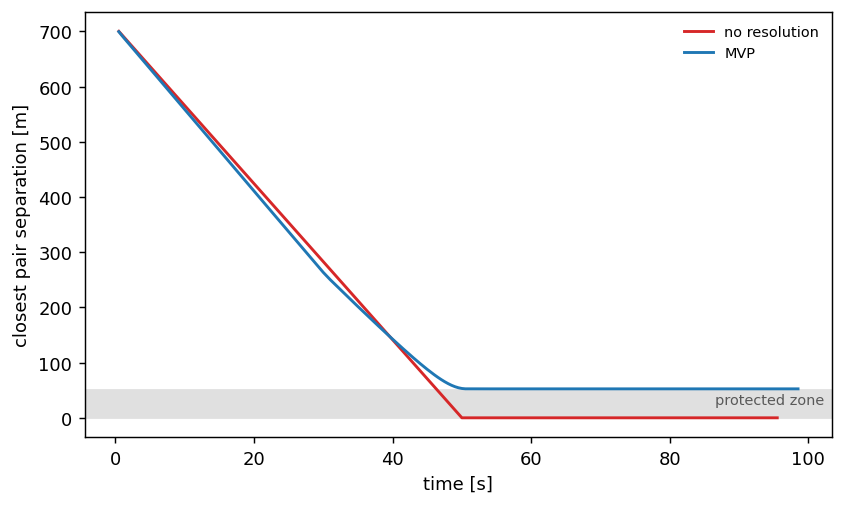

In [6]:
fig, ax = plt.subplots(figsize=(6.6, 4.0))
for run, label, colour in ((free, "no resolution", "#d62728"), (solved, "MVP", "#1f77b4")):
    t = np.array([f.t for f in run.frames.frames])
    sep = np.array([f.min_sep for f in run.frames.frames], dtype=float)
    ax.plot(t, np.where(np.isfinite(sep), sep, np.nan), lw=1.6, color=colour, label=label)
ax.axhspan(0, RPZ, color="0.88", zorder=0)
ax.annotate("protected zone", (0.99, RPZ * 0.5), xycoords=("axes fraction", "data"),
            ha="right", fontsize=8, color="0.35")
ax.set_xlabel("time [s]")
ax.set_ylabel("closest pair separation [m]")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()

Both fleets start a ring-diameter apart and close steadily. The unresolved one drives straight
through the shaded band to zero. The MVP one flattens out above it, holds while the drones file past
each other, then opens back up as they run for their goals.

## Turning up the number of drones

`N_DRONES` was a parameter all along, so the only thing that changes is the number:

N =  4   closest approach   52.5 m   separation lost: False   finished at 98 s
N =  8   closest approach   50.0 m   separation lost: False   finished at 106 s
N = 16   closest approach   43.2 m   separation lost:  True   finished at 210 s
N = 24   closest approach   42.5 m   separation lost:  True   finished at 234 s


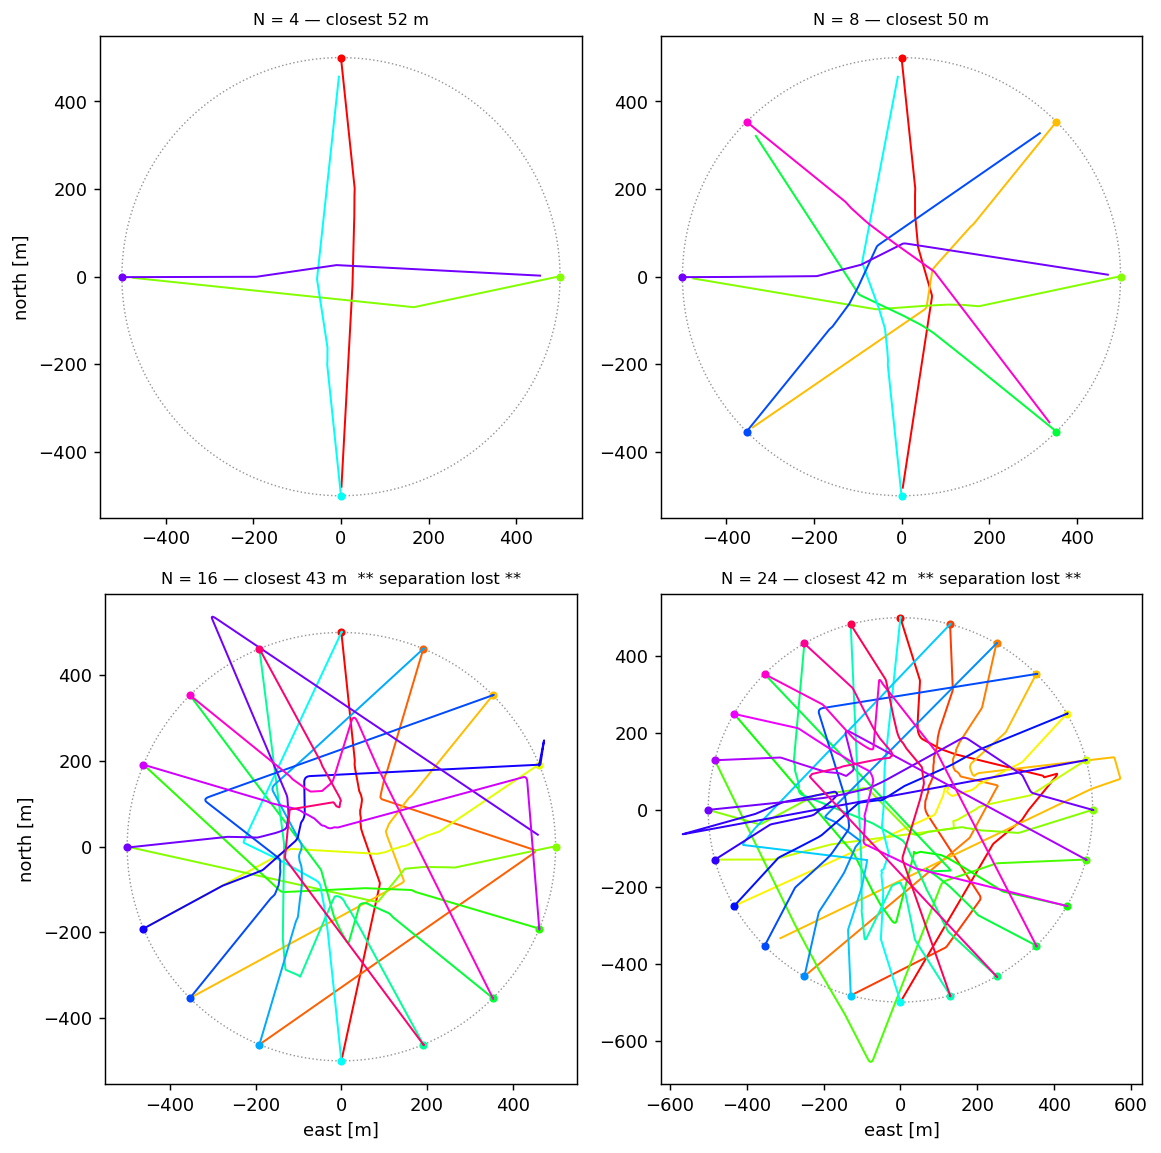

In [7]:
GRID = [4, 8, 16, 24]
runs = {n: fly(circle_fleet(n)[0], MVP(1.05)) for n in GRID}

fig, axes = plt.subplots(2, 2, figsize=(9.0, 9.0))
for ax, n in zip(axes.ravel(), GRID):
    r = runs[n]
    flag = "" if not r.los else "  ** separation lost **"
    draw_tracks(ax, r, f"N = {n} — closest {r.min_sep:.0f} m{flag}")
for ax in axes[0]:
    ax.set_xlabel("")
for ax in axes[:, 0]:
    ax.set_ylabel("north [m]")
fig.tight_layout()

for n in GRID:
    r = runs[n]
    print(f"N = {n:>2}   closest approach {r.min_sep:6.1f} m   separation lost: {str(r.los):>5}   "
          f"finished at {r.frames.frames[-1].t:.0f} s")

The rosette tightens as the ring fills up. `N = 16` is the clearest picture of what MVP is doing
here: the fleet has organised itself into a rotating pattern around a visibly **empty centre**. No
drone crosses the middle. Each one is turned aside early enough that the whole fleet flows around a
hole none of them was told to leave.

`N = 24` is different in kind, and it is worth noting how the axes change. Separation is lost, the
run never finishes — it burns the full 600 s with most of the fleet still short of its destination —
and the drones sprawl out past 700 m, well beyond the 500 m ring they started on. Rather than filing
through, they scatter into a tangle and keep milling. Everyone is pushing outward against everyone
else, the pushes largely cancel, and no one makes progress toward a goal.

## Sweeping the parameter

Four sizes are suggestive; sweeping shows the shape:

  N  ring spacing    closest   lost   arrived
  2        1000 m     50.4 m  False       yes
  3         866 m     78.4 m  False       yes
  4         707 m     52.5 m  False       yes
  5         588 m     50.2 m  False       yes
  6         500 m     50.3 m  False       yes
  8         383 m     50.0 m  False       yes
 10         309 m     50.5 m  False       yes
 12         259 m     47.4 m   True       yes
 14         223 m     46.8 m   True       yes
 16         195 m     43.2 m   True       yes
 18         174 m     50.1 m  False        NO
 20         156 m     46.0 m   True       yes
 22         142 m     50.0 m  False        NO
 24         131 m     42.5 m   True       yes


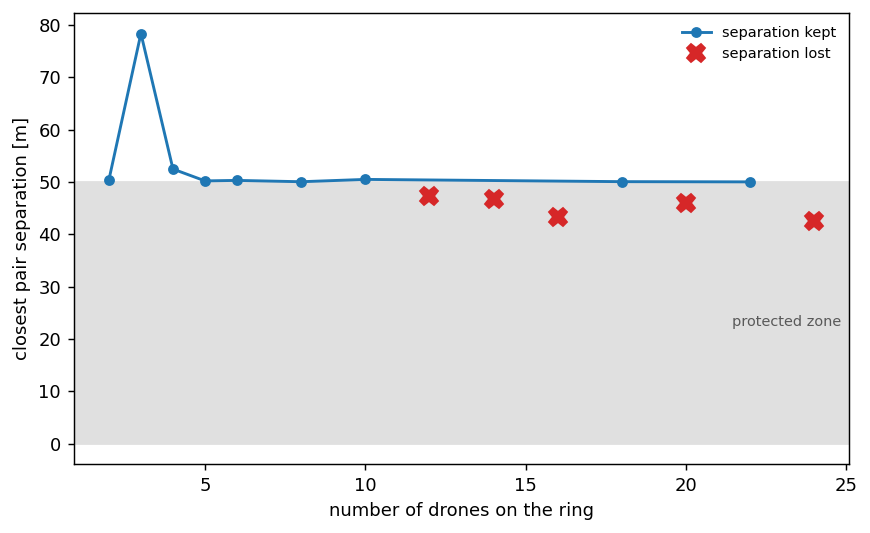

In [8]:
NS = [2, 3, 4, 5, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24]
sweep = {n: fly(circle_fleet(n)[0], MVP(1.05)) for n in NS}

ok = [(n, r.min_sep) for n, r in sweep.items() if not r.los]
bad = [(n, r.min_sep) for n, r in sweep.items() if r.los]

fig, ax = plt.subplots(figsize=(6.8, 4.2))
ax.plot([n for n, _ in ok], [m for _, m in ok], marker="o", ms=5, lw=1.6,
        color="#1f77b4", label="separation kept")
if bad:
    ax.plot([n for n, _ in bad], [m for _, m in bad], marker="X", ms=10, lw=0,
            color="#d62728", label="separation lost")
ax.axhspan(0, RPZ, color="0.88", zorder=0)
ax.annotate("protected zone", (0.99, RPZ * 0.45), xycoords=("axes fraction", "data"),
            ha="right", fontsize=8, color="0.35")
ax.set_xlabel("number of drones on the ring")
ax.set_ylabel("closest pair separation [m]")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()

print(f"{'N':>3} {'ring spacing':>13} {'closest':>10} {'lost':>6} {'arrived':>9}")
for n in NS:
    r = sweep[n]
    spacing = 2 * RADIUS * math.sin(math.pi / n)
    arrived = "yes" if r.frames.frames[-1].t < 600.0 else "NO"
    print(f"{n:>3} {spacing:>11.0f} m {r.min_sep:>8.1f} m {str(r.los):>6} {arrived:>9}")

Three things to read off this.

**The trend is downward, and it is crowding rather than distance.** Every drone flies the same
1000 m at the same speed regardless of `N`; what changes is how many others it must dodge on the
way. The starting positions never get close — even at `N = 24` the drones begin 131 m apart, well
outside the protected zone. All of the pressure is in the middle.

**The curve is bumpy, not smooth.** Counts of 3, 5 and 6 all clear by around 150 m, while 2, 4, 8
and 10 clear by around 100 m. That is structure rather than noise — these runs contain nothing
random, and rerunning reproduces the numbers exactly. Which counts come out well depends on how the
geometry lets the drones' outward pushes line up, and it is plainly not a simple function of `N`:
five does better than six, and six does better than eight.

**It breaks at 24.** Separation drops to about 40 m and the fleet never converges.

## A caution about the timestep

Before treating any large-`N` number as a property of MVP, it needs one more check. Runs this dense
are sensitive to how finely time is sliced, and the failures are the most sensitive part of all.

Two counts at three timesteps:

In [9]:
print(f"{'N':>3} {'dt':>6} {'closest':>10} {'lost':>6} {'finished':>10}")
for n in (20, 24):
    for dt in (1.0, 0.5, 0.25):
        r = fly(circle_fleet(n)[0], MVP(1.05), dt=dt)
        t_end = r.frames.frames[-1].t
        print(f"{n:>3} {dt:>6} {r.min_sep:>8.1f} m {str(r.los):>6} "
              f"{('yes' if t_end < 600.0 else 'NO'):>10}")
    print()

  N     dt    closest   lost   finished
 20    1.0     44.8 m   True        yes
 20    0.5     46.0 m   True        yes
 20   0.25     44.6 m   True        yes

 24    1.0     43.5 m   True        yes
 24    0.5     42.5 m   True        yes
 24   0.25     38.8 m   True        yes



 20   0.25     52.5 m  False        yes



 24    1.0     41.4 m   True         NO


 24    0.5     40.1 m   True         NO


 24   0.25     42.4 m   True         NO



The two rows behave completely differently, and the difference matters.

**`N = 20` fails at `dt = 1.0` and is fine at 0.5 and 0.25**, where the two finer runs agree closely
with each other. The coarse run is the outlier, so that failure is an artifact of the timestep — at
one-second steps the drones jump far enough between updates that the resolution misfires. Reporting
"MVP fails at 20 drones" from that one run would have been wrong.

**`N = 24` fails at all three**, with the same closest approach to within a couple of metres and the
same stalled fleet every time. Refining the timestep does not rescue it, and that is what makes it a
real result rather than a numerical one.

That is the whole check: **refine the timestep and see whether the finding survives.** It is cheap,
and here it was the difference between one true breakdown and one false alarm. The sweep above ran
at `dt = 0.5`; at `dt = 1.0` it would have shown two failures, one of them imaginary.

## Now with imperfect information

Everything so far has been a fantasy in one specific way: every drone knew exactly where every other
drone was, instantly and always. Switching that off is where the scenario gets interesting, because
the symmetry that made it hard was also holding it together.

The standard CNS stack is three models, and they compose into a chain:

| | model | what it does |
|---|---|---|
| **C** | `Comm` | broadcasts each drone's report. Messages can be **lost**, and arrive **late** |
| **N** | `GnssNavigation` | each drone measures **its own** position and velocity, with error |
| **S** | `LastKnown` | what a receiver believes about others: the last message it got, held as-is |

So a drone no longer reacts to where its neighbour *is*. It reacts to where that neighbour
*measured itself to be*, some time ago, if the message arrived at all. The settings below say: a
position fix good to 20 m and a velocity fix good to 2 m/s (both 95%), reports broadcast once a
second, one message in ten lost, and a typical delivery delay of 0.2 s.

Because there is randomness now, a run needs random streams — one each for navigation, the link,
and broadcast timing — all descended from a single seed so the run is repeatable.

perfect information:  closest   52.5 m,  lost: False,  finished at 98 s
with CNS (seed 0):    closest   63.5 m,  lost: False,  finished at 108 s


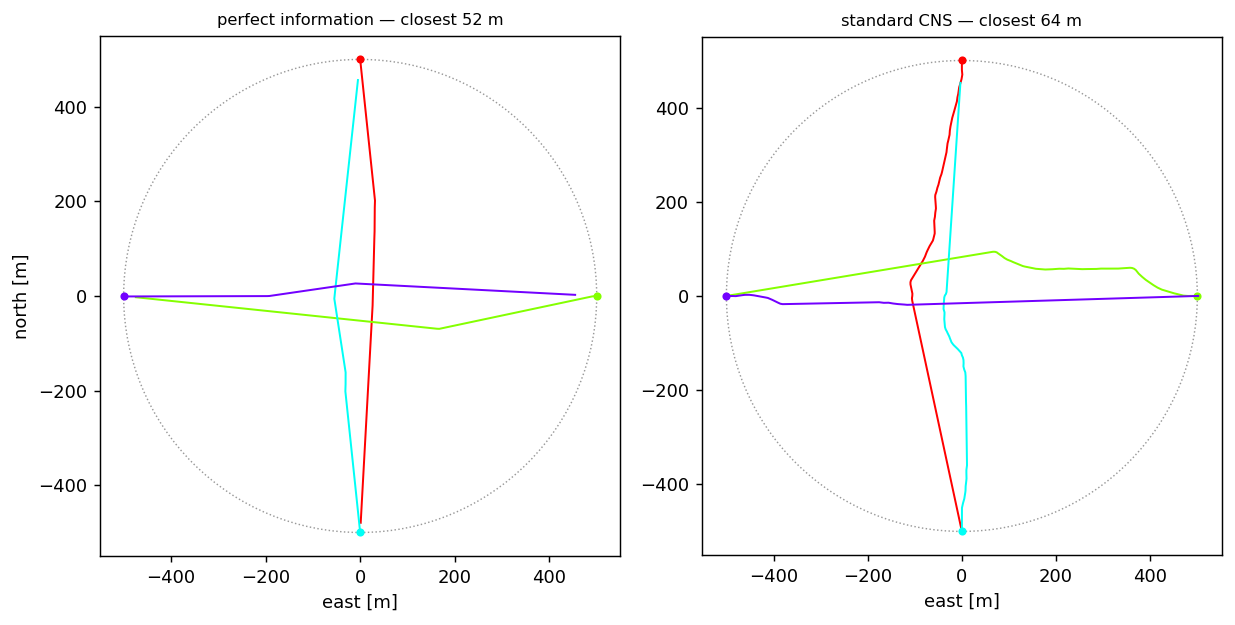

In [10]:
def fly_cns(n, seed, pos_ci95=20.0, vel_ci95=2.0, dt=0.5):
    # The same ring, flown with the standard CNS stack in place.
    nav_seq, comm_seq, bc_seq = spawn(root_seed_sequence(seed), 3)
    agents, _ = circle_fleet(n, pos_ci95=pos_ci95, vel_ci95=vel_ci95)
    return fly(
        agents, MVP(1.05), dt=dt,
        navigation=GnssNavigation(), rng=generator(nav_seq),
        communication=Comm(reception_prob=0.9, latency=lognormal_latency(0.2, 0.4)),
        comm_rng=generator(comm_seq),
        surveillance=LastKnown(),
        schedule=BroadcastSchedule(interval=1.0), broadcast_rng=generator(bc_seq),
    )


cns = fly_cns(N_DRONES, seed=0)
print(f"perfect information:  closest {solved.min_sep:6.1f} m,  lost: {str(solved.los):>5},  "
      f"finished at {solved.frames.frames[-1].t:.0f} s")
print(f"with CNS (seed 0):    closest {cns.min_sep:6.1f} m,  lost: {str(cns.los):>5},  "
      f"finished at {cns.frames.frames[-1].t:.0f} s")

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(9.6, 4.9))
draw_tracks(ax0, solved, f"perfect information — closest {solved.min_sep:.0f} m")
draw_tracks(ax1, cns, f"standard CNS — closest {cns.min_sep:.0f} m")
ax0.set_ylabel("north [m]")
fig.tight_layout()

The clean rosette is gone. The drones wander, correct, and overshoot, and the fleet takes noticeably
longer to clear — each one is chasing a picture of its neighbours that is a little wrong and a little
old, so it keeps re-deciding.

Something important has also changed about the experiment itself. **This run is one sample, not the
answer.** Change the seed and you get a different set of measurement errors, a different set of
dropped messages, and a different outcome. So the honest question is no longer "what is the closest
approach" but "what is the *spread* of closest approaches".

Twenty seeds at each of four fleet sizes:

In [11]:
SEEDS = range(20)
SIZES = [4, 8, 12, 16]

results = {n: [fly_cns(n, s) for s in SEEDS] for n in SIZES}

print(f"{'N':>3} {'perfect info':>14} | {'best':>7} {'median':>8} {'worst':>8} "
      f"{'lost separation':>17}")
for n in SIZES:
    seps = np.array([r.min_sep for r in results[n]])
    n_los = sum(r.los for r in results[n])
    print(f"{n:>3} {sweep[n].min_sep:>12.1f} m | {seps.max():>5.1f} m {np.median(seps):>6.1f} m "
          f"{seps.min():>6.1f} m {n_los:>10}/{len(SEEDS)}")

  N   perfect info |    best   median    worst   lost separation
  4         52.5 m |  75.0 m   66.1 m   58.8 m          0/20
  8         50.0 m |  61.9 m   50.2 m   24.3 m         10/20
 12         47.4 m |  60.5 m   42.6 m   13.1 m         16/20
 16         43.2 m |  43.6 m   33.3 m   14.4 m         20/20


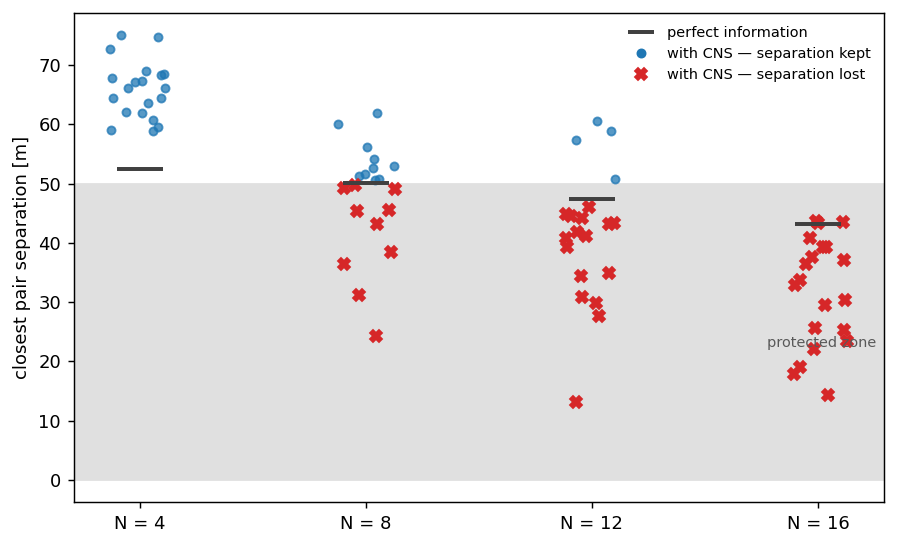

In [12]:
fig, ax = plt.subplots(figsize=(7.0, 4.3))
rng = np.random.default_rng(0)          # jitter only, so overlapping dots stay readable
for i, n in enumerate(SIZES):
    seps = np.array([r.min_sep for r in results[n]])
    lost = np.array([r.los for r in results[n]])
    x = i + rng.uniform(-0.13, 0.13, size=seps.size)
    ax.plot(x[~lost], seps[~lost], "o", ms=4.5, color="#1f77b4", alpha=0.75)
    ax.plot(x[lost], seps[lost], "X", ms=7, color="#d62728")
    ax.plot(i, sweep[n].min_sep, "_", ms=26, mew=2.2, color="0.25")

ax.axhspan(0, RPZ, color="0.88", zorder=0)
ax.annotate("protected zone", (0.99, RPZ * 0.45), xycoords=("axes fraction", "data"),
            ha="right", fontsize=8, color="0.35")
ax.set_xticks(range(len(SIZES)))
ax.set_xticklabels([f"N = {n}" for n in SIZES])
ax.set_ylabel("closest pair separation [m]")
ax.plot([], [], "_", ms=14, mew=2.2, color="0.25", label="perfect information")
ax.plot([], [], "o", ms=4.5, color="#1f77b4", label="with CNS — separation kept")
ax.plot([], [], "X", ms=7, color="#d62728", label="with CNS — separation lost")
ax.legend(frameon=False, fontsize=8, loc="upper right")
fig.tight_layout()

The grey dash is the perfect-information run from the sweep; the dots are the twenty CNS runs.

**Uncertainty costs more than crowding does.** With perfect information the ring survived all the
way to 22 drones. With a fairly ordinary CNS stack it is already losing separation in most runs at
twelve — and it fails occasionally even at four, where the clean run cleared by more than 100 m. The
sensor and datalink move the outcome further than doubling the traffic did.

**It usually costs margin, but not always.** The median of every column sits below its
perfect-information dash, and the gap widens as the fleet grows. But the dots are not all below it —
at `N = 4` three of the twenty beat the clean run outright, because an error that happens to push a
drone the helpful way buys it extra room. The errors themselves are symmetric; what is asymmetric is the
consequence. Being pushed wide costs a slightly longer detour, while being pushed in costs
separation, so the bottom of the distribution moves further than the top.

**The spread is wide.** At `N = 4` the twenty runs range from 50 m to 146 m off the same starting
geometry — a factor of three, with the geometry held identical and only the measurement errors and
dropped messages differing. This is exactly why a single run cannot answer a safety question here,
and why the counts above are written as "13 out of 20" rather than as a probability. Twenty runs pin
a rate down only very loosely; a real answer needs the estimators, which exist to run this many
times over and report an interval with the number.

## Things to try from here

- **Change `N_DRONES` and rerun.** Everything downstream follows the parameter.
- **Dial the CNS settings.** `pos_ci95` and `vel_ci95` on `fly_cns`, and `reception_prob` and the
  latency inside `Comm`, are the four knobs that matter most. Setting `reception_prob=1.0` and the
  latency to zero, while keeping the position error, separates "I cannot see you well" from "I
  cannot hear you reliably".
- **Swap the resolver.** `VO(1.05)` drops into the same slot as `MVP(1.05)`. It reasons about
  forbidden velocity sets rather than summed pushes, so it responds differently when many intruders
  arrive at once.
- **Change the ring instead of the count.** Shrinking `RADIUS` leaves less room to resolve in;
  raising `SPEED` leaves less time. Both tighten the same screw as adding drones.
- **Ask for a probability.** The twenty-seed counts above are a sketch of the right answer. Turning
  them into a rate with an interval around it is the job of the estimators.